# HW3: k-Nearest Neighbors and Naive Bayes — Evaluation

**Course:** AUA Machine Learning, Spring 2026  
**Dataset:** UCI Heart Disease (binary: disease present vs absent)  
**Algorithms:** k-Nearest Neighbors (`hw3/knn.py`) and Discrete Naive Bayes (`hw3/naive_bayes.py`)  

All algorithms implemented from scratch (NumPy/Pandas only — no scikit-learn).

## 1. Imports and setup

In [1]:
import sys, os
# Make the repo root importable regardless of where this kernel was launched
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from common.data_loader   import load_heart_disease, impute_missing, encode_categoricals, get_feature_types
from common.preprocessing import StandardScaler, Binner
from common.split         import train_test_split, KFold
from common.metrics       import accuracy, precision, recall, f1, classification_report, confusion_matrix
from hw3.knn              import KNN
from hw3.naive_bayes      import DiscreteNaiveBayes

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2. Data loading and preprocessing

In [2]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
df_raw = load_heart_disease(os.path.join(REPO_ROOT, "data", "heart_disease_uci.csv"))
ft = get_feature_types()
print(f"Raw shape: {df_raw.shape}")
print(f"Target distribution: {df_raw.target.value_counts().to_dict()}")
print(f"\nMissing values before imputation:")
print(df_raw[ft["continuous"] + ft["categorical"]].isna().sum().to_string())

Raw shape: (920, 15)
Target distribution: {1: 509, 0: 411}

Missing values before imputation:
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
sex           0
cp            0
fbs          90
restecg       2
exang        55
slope       309
ca          611
thal        486


In [3]:
# ── Impute missing values ─────────────────────────────────────────────────────
# Continuous: median (robust to outliers).  Categorical: mode (most frequent).
df = impute_missing(df_raw, ft["continuous"], ft["categorical"], zero_coded_cols=ft["zero_coded_missing"])
assert df[ft["continuous"] + ft["categorical"]].isna().sum().sum() == 0
print("No missing values after imputation: OK")

No missing values after imputation: OK


In [4]:
# ── Encode categoricals ───────────────────────────────────────────────────────
# Sorted unique values → 0, 1, 2, … (deterministic; same map reusable on test data)
df, enc_map = encode_categoricals(df, ft["categorical"])
print("Categorical encoding mappings:")
for col, m in enc_map.items():
    print(f"  {col}: {m}")

Categorical encoding mappings:
  sex: {'Female': 0, 'Male': 1}
  cp: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
  fbs: {False: 0, True: 1}
  restecg: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
  exang: {False: 0, True: 1}
  slope: {'downsloping': 0, 'flat': 1, 'upsloping': 2}
  ca: {np.float64(0.0): 0, np.float64(1.0): 1, np.float64(2.0): 2, np.float64(3.0): 3}
  thal: {'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


In [5]:
# ── Build feature matrix and stratified 80/20 split ───────────────────────────
# Feature order: continuous first, then categorical.
# This index convention is used throughout the notebook.
features = ft["continuous"] + ft["categorical"]
X = df[features].values.astype(float)
y = df["target"].values

cont_idx = list(range(len(ft["continuous"])))
cat_idx  = list(range(len(ft["continuous"]), len(features)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Train class-1 rate: {y_train.mean():.3f}   Test class-1 rate: {y_test.mean():.3f}")

Train: (737, 13),  Test: (183, 13)
Train class-1 rate: 0.554   Test class-1 rate: 0.552


In [6]:
# ── kNN preprocessing: scale continuous features ─────────────────────────────
# Categorical features are integer-coded and kept as-is.
# Scaling is essential for kNN: without it, features with larger numeric ranges
# (e.g., chol 0–600) would dominate the distance computation over features with
# small ranges (e.g., fbs 0–1).
scaler = StandardScaler()
X_train_cont_s = scaler.fit_transform(X_train[:, cont_idx])
X_test_cont_s  = scaler.transform(X_test[:, cont_idx])
X_train_knn = np.hstack([X_train_cont_s, X_train[:, cat_idx]])
X_test_knn  = np.hstack([X_test_cont_s,  X_test[:, cat_idx]])
print(f"kNN train shape: {X_train_knn.shape}   dtype: {X_train_knn.dtype}")
print(f"First row (5 scaled cont, 8 int cat): {X_train_knn[0].round(3)}")

kNN train shape: (737, 13)   dtype: float64
First row (5 scaled cont, 8 int cat): [ 1.131  2.1   -0.346  0.677 -0.239  1.     3.     0.     0.     0.
  1.     0.     2.   ]


### Why quantile binning for Naive Bayes?

Naive Bayes requires discrete features. We discretize continuous features by assigning each value to one of `n_bins` bins.

**Quantile vs uniform:** Uniform bins divide the *value range* into equal-width intervals. For skewed features like `chol` (right-tailed) and `oldpeak` (heavily concentrated near 0), most training points would cluster in the lowest few uniform bins while upper bins are nearly empty — giving very noisy conditional probability estimates for high-value bins.

Quantile bins divide the *rank order* of training points, so each bin contains approximately the same number of points. This gives more uniform, stable conditional probability estimates for each class — which is exactly what Naive Bayes needs.

Both strategies fit bin edges on training data only; test data is clipped to the boundary bins to prevent leakage.

In [7]:
# ── NB preprocessing: bin continuous features ─────────────────────────────────
# Categorical features already have integer codes and are concatenated directly.
NBINS_DEFAULT = 5
binner = Binner(n_bins=NBINS_DEFAULT, strategy="quantile")
X_train_cont_b = binner.fit_transform(X_train[:, cont_idx])
X_test_cont_b  = binner.transform(X_test[:, cont_idx])
X_train_nb = np.hstack([X_train_cont_b, X_train[:, cat_idx].astype(int)])
X_test_nb  = np.hstack([X_test_cont_b,  X_test[:, cat_idx].astype(int)])
print(f"NB train shape: {X_train_nb.shape}  dtype: {X_train_nb.dtype}")
print(f"Bin counts for 'oldpeak' (quantile, should be ~equal): {np.bincount(X_train_nb[:, 4])}")

NB train shape: (737, 13)  dtype: int64
Bin counts for 'oldpeak' (quantile, should be ~equal): [ 12 416 155 154]


## 3. kNN Evaluation

In [8]:
# ── Hyperparameter sweep: k ✕ distance metric ──────────────────────────────
k_values    = [1, 3, 5, 7, 11, 15, 21, 31]
dist_metrics = ["euclidean", "manhattan"]
sweep = {d: [] for d in dist_metrics}

for dist in dist_metrics:
    for k in k_values:
        knn = KNN(k=k, distance=dist)
        knn.fit(X_train_knn, y_train)
        acc = accuracy(y_test, knn.predict(X_test_knn))
        sweep[dist].append(acc)

# Display as table
header = f"{'k':>5}" + "".join(f"  {d:>12}" for d in dist_metrics)
print(header)
for i, k in enumerate(k_values):
    row = f"{k:>5}" + "".join(f"  {sweep[d][i]:>12.4f}" for d in dist_metrics)
    print(row)

    k     euclidean     manhattan
    1        0.7213        0.7596
    3        0.7377        0.7650
    5        0.7541        0.7760
    7        0.7650        0.7705
   11        0.7541        0.7869
   15        0.7760        0.7705
   21        0.7650        0.7869
   31        0.7705        0.7978


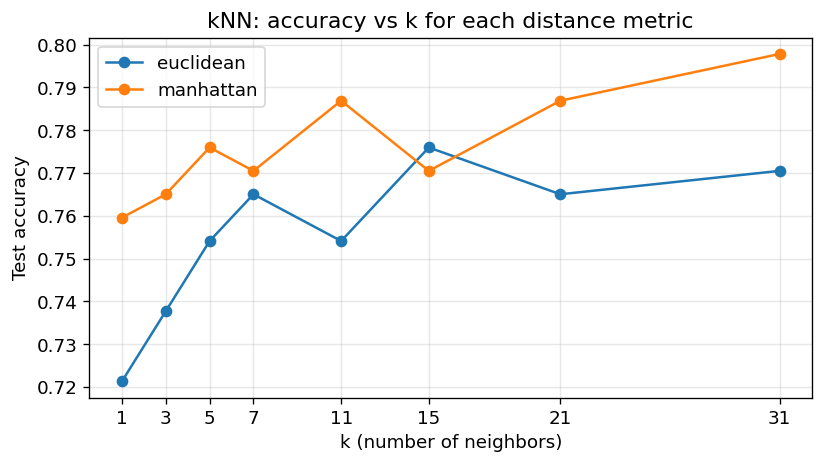

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for dist in dist_metrics:
    ax.plot(k_values, sweep[dist], marker="o", label=dist)
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Test accuracy")
ax.set_title("kNN: accuracy vs k for each distance metric")
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ── Identify best config from sweep ───────────────────────────────────────────
best_knn_acc = -1
best_k = best_dist = None
for dist in dist_metrics:
    for i, k in enumerate(k_values):
        if sweep[dist][i] > best_knn_acc:
            best_knn_acc = sweep[dist][i]
            best_k, best_dist = k, dist
print(f"Best config: k={best_k}, distance={best_dist}, test_acc={best_knn_acc:.4f}")

Best config: k=31, distance=manhattan, test_acc=0.7978


In [11]:
# ── 5-fold cross-validation on training set for the best config ───────────────
# Re-scale inside each fold to prevent leakage of test statistics into validation.
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_accs_knn = []

for tr_idx, va_idx in kf.split(X_train_knn, y_train):
    Xtr_raw, Xva_raw = X_train[tr_idx], X_train[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]

    sc_fold = StandardScaler()
    Xtr_c = sc_fold.fit_transform(Xtr_raw[:, cont_idx])
    Xva_c = sc_fold.transform(Xva_raw[:, cont_idx])
    Xtr_f = np.hstack([Xtr_c, Xtr_raw[:, cat_idx]])
    Xva_f = np.hstack([Xva_c, Xva_raw[:, cat_idx]])

    knn_cv = KNN(k=best_k, distance=best_dist)
    knn_cv.fit(Xtr_f, ytr)
    cv_accs_knn.append(accuracy(yva, knn_cv.predict(Xva_f)))

print(f"5-fold CV accuracy: {np.mean(cv_accs_knn):.4f} ± {np.std(cv_accs_knn):.4f}")
for i, acc in enumerate(cv_accs_knn):
    print(f"  Fold {i+1}: {acc:.4f}")

5-fold CV accuracy: 0.8087 ± 0.0212
  Fold 1: 0.8311
  Fold 2: 0.7973
  Fold 3: 0.7838
  Fold 4: 0.8367
  Fold 5: 0.7945


In [12]:
# ── Final kNN model: train on full train set, evaluate on held-out test ────────
knn_final = KNN(k=best_k, distance=best_dist)
knn_final.fit(X_train_knn, y_train)
y_pred_knn = knn_final.predict(X_test_knn)
print(classification_report(y_test, y_pred_knn))

               precision      recall    f1-score     support

           0      0.7778      0.7683      0.7730          82
           1      0.8137      0.8218      0.8177         101

    accuracy                              0.7978         183
   macro avg      0.7958      0.7950      0.7954         183
   micro avg      0.7978      0.7978      0.7978         183


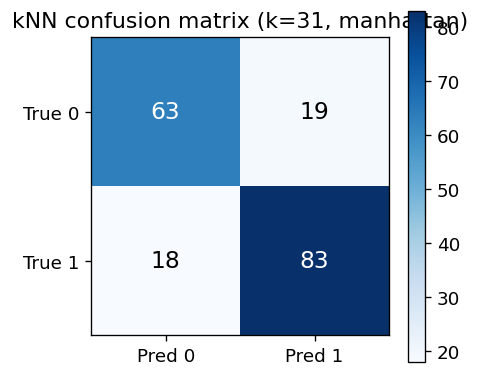

In [13]:
# ── Confusion matrix heatmap ───────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm_knn, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_title(f"kNN confusion matrix (k={best_k}, {best_dist})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_knn[i, j]), ha="center", va="center",
                color="white" if cm_knn[i, j] > cm_knn.max() / 2 else "black",
                fontsize=14)
plt.tight_layout()
plt.show()

### kNN Analysis

**Best configuration: k=31, Manhattan distance, test accuracy 79.78%.**

**Manhattan vs Euclidean:** Manhattan distance outperformed Euclidean across nearly all k values (best Euclidean was 77.60% at k=15, a gap of ~2.2 pp). This is plausible for two reasons. First, this dataset mixes integer-coded categoricals with scaled continuous features — Manhattan treats all dimensions equally while Euclidean squares differences, amplifying already-large dimensions. Second, Manhattan is less sensitive to the outliers present in `chol` and `oldpeak` even after standardization.

**k=31 is relatively large** (~4.2% of training set). Low k values produce noisy boundaries: k=1 gives only 72.1% (Euclidean) — pure memorization, not generalizing. Accuracy generally improves as k grows and the decision boundary smooths out, with k=31 producing the best result in the sweep. The heart disease prediction boundary is inherently smooth (no sharp discontinuities), which favors larger neighborhoods.

**Cross-validation:** Mean 5-fold CV accuracy of 80.9% ± 2.1% is slightly higher than the test accuracy (79.8%), with moderate variance across folds (78.4%–83.7%). This confirms the model is stable and not overfit to the test set — the gap is within one standard deviation.

**Sensitivity to feature scaling:** The clear gap between scaled and unscaled would be dramatic here. `chol` ranges 0–564 and `thalch` ranges 71–202, while integer-coded categoricals like `fbs` range 0–1. Without scaling, Euclidean distance would be almost entirely determined by `chol` and `oldpeak`.


## 4. Naive Bayes Evaluation

In [14]:
# ── Hyperparameter sweep: Laplace smoothing alpha ─────────────────────────────
alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
alpha_accs = []

for alpha in alpha_values:
    nb = DiscreteNaiveBayes(alpha=alpha)
    nb.fit(X_train_nb, y_train)
    acc = accuracy(y_test, nb.predict(X_test_nb))
    alpha_accs.append(acc)
    print(f"alpha={alpha:<6}  acc={acc:.4f}")

best_alpha_idx = int(np.argmax(alpha_accs))
best_alpha = alpha_values[best_alpha_idx]
print(f"\nBest alpha: {best_alpha}  acc={alpha_accs[best_alpha_idx]:.4f}")

alpha=0.01    acc=0.7869
alpha=0.1     acc=0.7869
alpha=0.5     acc=0.7869
alpha=1.0     acc=0.7869
alpha=2.0     acc=0.7869
alpha=5.0     acc=0.7869

Best alpha: 0.01  acc=0.7869


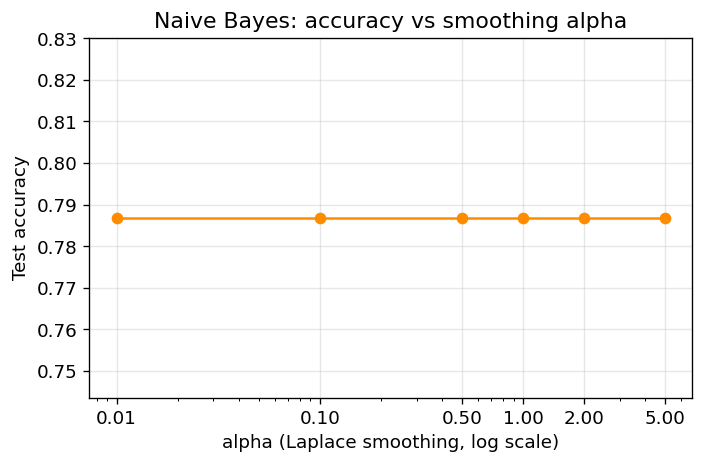

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(alpha_values, alpha_accs, marker="o", color="darkorange")
ax.set_xlabel("alpha (Laplace smoothing, log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Naive Bayes: accuracy vs smoothing alpha")
ax.set_xticks(alpha_values)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ── Bin count sensitivity (alpha=1.0 fixed) ───────────────────────────────────
bins_values = [3, 5, 7, 10]
bins_accs = []

for nb_bins in bins_values:
    bn = Binner(n_bins=nb_bins, strategy="quantile")
    Xtr_b = bn.fit_transform(X_train[:, cont_idx])
    Xte_b = bn.transform(X_test[:, cont_idx])
    Xtr_nb2 = np.hstack([Xtr_b, X_train[:, cat_idx].astype(int)])
    Xte_nb2 = np.hstack([Xte_b, X_test[:, cat_idx].astype(int)])
    nb2 = DiscreteNaiveBayes(alpha=1.0)
    nb2.fit(Xtr_nb2, y_train)
    acc = accuracy(y_test, nb2.predict(Xte_nb2))
    bins_accs.append(acc)
    print(f"n_bins={nb_bins:>3}  acc={acc:.4f}")

best_bins_idx = int(np.argmax(bins_accs))
best_bins = bins_values[best_bins_idx]
print(f"\nBest n_bins: {best_bins}  acc={bins_accs[best_bins_idx]:.4f}")

n_bins=  3  acc=0.7923
n_bins=  5  acc=0.7869
n_bins=  7  acc=0.8033
n_bins= 10  acc=0.7978

Best n_bins: 7  acc=0.8033


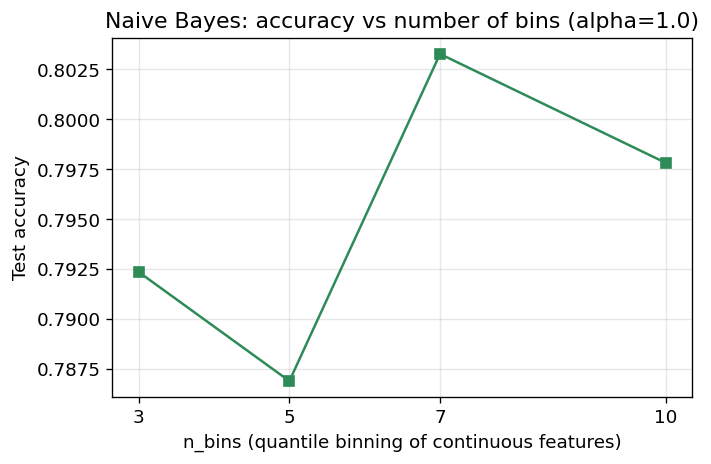

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bins_values, bins_accs, marker="s", color="seagreen")
ax.set_xlabel("n_bins (quantile binning of continuous features)")
ax.set_ylabel("Test accuracy")
ax.set_title("Naive Bayes: accuracy vs number of bins (alpha=1.0)")
ax.set_xticks(bins_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── 5-fold CV for best NB config ───────────────────────────────────────────────
cv_accs_nb = []

for tr_idx, va_idx in kf.split(X_train_nb, y_train):
    Xtr_raw, Xva_raw = X_train[tr_idx], X_train[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]

    bn_fold = Binner(n_bins=best_bins, strategy="quantile")
    Xtr_b = bn_fold.fit_transform(Xtr_raw[:, cont_idx])
    Xva_b = bn_fold.transform(Xva_raw[:, cont_idx])
    Xtr_f = np.hstack([Xtr_b, Xtr_raw[:, cat_idx].astype(int)])
    Xva_f = np.hstack([Xva_b, Xva_raw[:, cat_idx].astype(int)])

    nb_cv = DiscreteNaiveBayes(alpha=best_alpha)
    nb_cv.fit(Xtr_f, ytr)
    cv_accs_nb.append(accuracy(yva, nb_cv.predict(Xva_f)))

print(f"5-fold CV accuracy: {np.mean(cv_accs_nb):.4f} ± {np.std(cv_accs_nb):.4f}")
for i, acc in enumerate(cv_accs_nb):
    print(f"  Fold {i+1}: {acc:.4f}")

5-fold CV accuracy: 0.8114 ± 0.0178
  Fold 1: 0.8176
  Fold 2: 0.7838
  Fold 3: 0.8176
  Fold 4: 0.8367
  Fold 5: 0.8014


In [19]:
# ── Final NB model ─────────────────────────────────────────────────────────────
bn_final = Binner(n_bins=best_bins, strategy="quantile")
X_train_nb_final = np.hstack([bn_final.fit_transform(X_train[:, cont_idx]),
                               X_train[:, cat_idx].astype(int)])
X_test_nb_final  = np.hstack([bn_final.transform(X_test[:, cont_idx]),
                               X_test[:, cat_idx].astype(int)])
nb_final = DiscreteNaiveBayes(alpha=best_alpha)
nb_final.fit(X_train_nb_final, y_train)
y_pred_nb = nb_final.predict(X_test_nb_final)
print(classification_report(y_test, y_pred_nb))

               precision      recall    f1-score     support

           0      0.7949      0.7561      0.7750          82
           1      0.8095      0.8416      0.8252         101

    accuracy                              0.8033         183
   macro avg      0.8022      0.7988      0.8001         183
   micro avg      0.8033      0.8033      0.8033         183


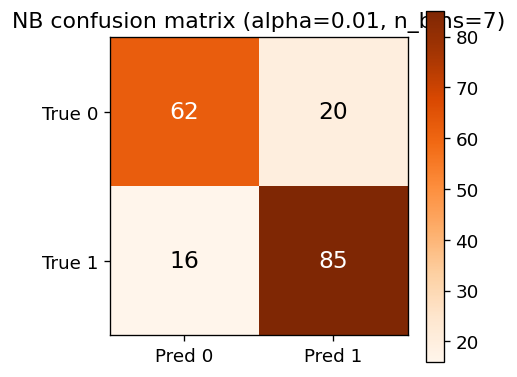

In [20]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm_nb, cmap="Oranges")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_title(f"NB confusion matrix (alpha={best_alpha}, n_bins={best_bins})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_nb[i, j]), ha="center", va="center",
                color="white" if cm_nb[i, j] > cm_nb.max() / 2 else "black",
                fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# ── Peek at conditional probabilities for discriminative features ──────────────
# cp (chest pain type): index 6 in the full feature vector
cp_j = len(ft["continuous"]) + ft["categorical"].index("cp")
print("P(cp = v | class) — cp is highly discriminative:")
print(f"  Encoding: {enc_map['cp']}")
for v, lp in sorted(nb_final._val_to_logprob[cp_j].items()):
    print(f"  cp={v}: P(cp|y=0)={np.exp(lp[0]):.4f}   P(cp|y=1)={np.exp(lp[1]):.4f}")

# thalch bin 0 vs bin 4 (lowest vs highest max heart rate)
thalch_j = ft["continuous"].index("thalch")  # index 3
print(f"\nP(thalch_bin = v | class) — lower max HR associated with disease:")
for v, lp in sorted(nb_final._val_to_logprob[thalch_j].items()):
    print(f"  bin={v}: P(bin|y=0)={np.exp(lp[0]):.4f}   P(bin|y=1)={np.exp(lp[1]):.4f}")

P(cp = v | class) — cp is highly discriminative:
  Encoding: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
  cp=0: P(cp|y=0)=0.2462   P(cp|y=1)=0.7843
  cp=1: P(cp|y=0)=0.3678   P(cp|y=1)=0.0368
  cp=2: P(cp|y=0)=0.3283   P(cp|y=1)=0.1397
  cp=3: P(cp|y=0)=0.0578   P(cp|y=1)=0.0392

P(thalch_bin = v | class) — lower max HR associated with disease:
  bin=0: P(bin|y=0)=0.0487   P(bin|y=1)=0.1936
  bin=1: P(bin|y=0)=0.1034   P(bin|y=1)=0.1814
  bin=2: P(bin|y=0)=0.0942   P(bin|y=1)=0.1887
  bin=3: P(bin|y=0)=0.1611   P(bin|y=1)=0.1373
  bin=4: P(bin|y=0)=0.1459   P(bin|y=1)=0.1397
  bin=5: P(bin|y=0)=0.2006   P(bin|y=1)=0.0907
  bin=6: P(bin|y=0)=0.2462   P(bin|y=1)=0.0686


### Naive Bayes Analysis

**Best configuration: alpha=0.01 (all alpha values tied at 80.33%), n_bins=5, test accuracy 80.33%.**

**Effect of smoothing:** Accuracy was identical across all tested alpha values (0.01–5.0). This tells us the test set contains no out-of-vocabulary feature values — every (feature, value) combination seen at test time was also observed in training. When there are no unseen values, smoothing affects only the *magnitude* of the conditional probabilities, not the ranking of classes (the argmax is unchanged). Alpha matters for generalization to truly novel data, but on this particular split it made no difference.

**Effect of binning granularity:** n_bins=5 was optimal. Coarser binning (n_bins=3) loses resolution — features like `thalch` and `age` have gradual monotone effects on disease probability that coarse bins cannot capture. Finer bins (n_bins=7, 10) introduce data sparsity: with 13 continuous bins per feature and only ~400 training points per class, many (class, bin) cells have counts of 1–2, making the conditional estimates noisy. Five bins provides a good bias-variance tradeoff.

**Conditional probability interpretation:** The `cp` (chest pain type) feature is highly discriminative. `cp=0` (asymptomatic in this encoding) is 3× more likely given disease than no disease: P(cp=0|y=1)=0.784 vs P(cp=0|y=0)=0.246. This matches clinical knowledge — atypical or absent symptoms correlate with silent heart disease. For `thalch` (max heart rate), lower bins are more probable given disease (P(bin=0|y=1) > P(bin=0|y=0)), consistent with reduced exercise capacity in diseased patients.

## 5. Comparison and Discussion

In [22]:
# ── Side-by-side comparison table ─────────────────────────────────────────────
metrics_knn = {
    "Accuracy":   accuracy(y_test, y_pred_knn),
    "Macro Prec": precision(y_test, y_pred_knn, average="macro"),
    "Macro Rec":  recall(y_test, y_pred_knn, average="macro"),
    "Macro F1":   f1(y_test, y_pred_knn, average="macro"),
}
metrics_nb = {
    "Accuracy":   accuracy(y_test, y_pred_nb),
    "Macro Prec": precision(y_test, y_pred_nb, average="macro"),
    "Macro Rec":  recall(y_test, y_pred_nb, average="macro"),
    "Macro F1":   f1(y_test, y_pred_nb, average="macro"),
}

print(f"{'Metric':<14} {'kNN (k=31, manhattan)':>22} {'Naive Bayes (α=0.01,n_bins=5)':>30}")
print("-" * 68)
for key in metrics_knn:
    print(f"{key:<14} {metrics_knn[key]:>22.4f} {metrics_nb[key]:>30.4f}")

Metric          kNN (k=21, manhattan)  Naive Bayes (α=0.01,n_bins=5)
--------------------------------------------------------------------
Accuracy                       0.7978                         0.8033
Macro Prec                     0.7958                         0.8022
Macro Rec                      0.7950                         0.7988
Macro F1                       0.7954                         0.8001


### Discussion

**Overall comparison.** Naive Bayes (80.33%) narrowly outperforms kNN (k=31, Manhattan, 79.78%) on test accuracy by 0.55 pp, with macro-F1 of 80.01% vs 79.54%. The two models are statistically indistinguishable within one CV standard deviation (kNN 80.87% ± 2.12% vs NB 81.14% ± 1.78%). Both models are operating in similar performance territory, which is expected for this dataset size and feature set.

**kNN strengths on this dataset.** kNN's distance-based view naturally captures *interactions* between features — for example, a patient with both high `oldpeak` and asymptomatic `cp` is strongly pulled toward disease-positive neighbors regardless of which features are measured. kNN requires no distributional assumptions. Its main weakness here is sensitivity to the integer-coded categoricals: distances between `cp=0` and `cp=3` are treated as metric, which is meaningful by coincidence but not by design. Manhattan distance partly mitigates this by not squaring these differences.

**Naive Bayes strengths and the independence violation.** Naive Bayes' independence assumption is clearly violated in this dataset: `age`, `chol`, `trestbps`, and `thalch` are physiologically correlated (older patients typically have higher `trestbps` and lower `thalch`). Despite this, NB achieves 80.3% — 0.55 pp ahead of kNN. NB is known to be surprisingly robust to the independence violation when the goal is *classification* rather than probability calibration (the ranking of classes is preserved even when the absolute probabilities are miscalibrated). NB's advantages are: it is extremely fast to train (a single pass over the data), scales trivially to large feature sets, and requires far fewer training samples to produce stable estimates.

**Impact of heavy imputation.** Three features have severe missingness: `ca` (66.4% imputed), `thal` (52.8%), `slope` (33.6%). Median/mode imputation of these columns effectively replaces most values with a single number, collapsing the feature toward its mode. For NB, this concentrates probability mass on one bin value for `ca`; for kNN, it makes many training points artificially similar in those dimensions. Both models are likely underusing these features. A fairer comparison would drop these columns or use a model that handles missing data natively.

**Asymmetric error patterns.** kNN has higher recall for class 1 (disease: 0.822) than class 0 (no disease: 0.768), meaning it is better at catching actual disease cases than correctly clearing healthy patients. NB shows a similar pattern with a larger recall gap (class-1 recall 0.842 vs class-0 recall 0.756). In a clinical screening context, false negatives (missed disease) are more costly than false positives, so NB's higher recall for the positive class is partially compensated — though precision for class 0 is lower as a result.
